**Purpose:** Download and filter the Reddit dump (Academic Torrents, see 01_data/README) into `reddit.parquet`.

**Inputs:** `reddit/reddit.parquet`, `reddit_filtered/reddit/aaaa.parquet`, `reddit_filtered/reddit/comments.parquet`

**Outputs:** `01_data/processed/reddit_0.parquet`, `reddit_filtered/reddit/aaaa.parquet`, `reddit_filtered/reddit/comments.parquet`, `reddit_filtered/reddit/reddit.parquet`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


# Reddit Data Extraction

The main goal of this notebook is to conduct the data extracition related to reddit posts and comments from the subreddits r/stocks, r/wallstreetbets, and r/investing [**5530e**, **cc28c**]

The most common way for this extraction was to use the Pushshift API, which provides a simple way to access historical Reddit data, including posts and comments from specific subreddits, like it was done in [**7eec7**] and [**cc28c**].

Pushshift makes it much easier (than Reddit API) for researchers to query and retrieve historical Reddit data, provides extended functionality by providing full-text search against comments and submissions, and has larger single query limits. Specifically, because, at the time of this writing, Pushshift has a size limit five times greater than Reddit’s 100 object limit, Pushshift enables the end user to quickly ingest large amounts of data. Additionally, the Pushshift API offers aggregation endpoints to provide summary analysis of Reddit activity, a feature that the Reddit API lacks entirely. [**7eec7** (The Pushshift Reddit Dataset)]

Although the Pushshift API has been limited since August 2023 for moderation use cases only, for Reddit Moderators, requiring the explicit approval from Reddit [**f4526**].

Other alternatives are the use of web-scraping tools [**5530e**], the Reddit API [**da676**], or Academic Torrents (such as [**74e30**, **8fee4**, **9c4f7**]).

Note: I emailed [**7eec7**] to request access to the dataset and they answered me saying to use the Academic Torrents (semi-annual historical data or monthly snapshots):

- [**8fee4**] https://academictorrents.com/details/30dee5f0406da7a353aff6a8caa2d54fd01f2ca1
- ~~[**9c4f7**] https://academictorrents.com/browse.php?search=RaiderBDev~~

Taking this into account, I will be using [**8fee4**] in order to get the historical data (2005-06 to 2025-06)~~, and afterwards [**9c4f7**] for the most recent monthly snapshots (from 2025-07)~~.

## [8fee4] using Google Colab

In [113]:
# # ================================
# # Step 0: Install dependencies
# # ================================
# !apt-get update
# !apt-get install -y aria2 zstd
# !pip install orjson tqdm torrentool

# import os
# from tqdm.notebook import tqdm
# import zstandard as zstd
# import orjson
# from google.colab import files
# from torrentool.api import Torrent
# import glob
# import io
# import shutil
# import json

# from google.colab import drive
# drive.mount('/content/drive')

# # ================================
# # Step 1: Upload your .torrent file
# # ================================
# torrent_file = "reddit-30dee5f0406da7a353aff6a8caa2d54fd01f2ca1.torrent"
# print(f"Using torrent: {torrent_file}")

# torrent = Torrent.from_file(torrent_file)

# print("Files in torrent:\n")
# for idx, f in enumerate(torrent.files):
#     print(f"{idx}: {f.name} ({f.length / 1e9:.2f} GB)")

# # ================================
# # Step 2: Iterate over files
# # ================================
# # Map filenames to their index
# file_map = {f.name: idx + 1 for idx, f in enumerate(torrent.files)}

# files_done = []

# for file_name in file_map:
#     if any(id in file_name for id in files_done):
#         continue

#     file_index = file_map[file_name]
#     print(f"File '{file_name}' found at index {file_index}")

#     # ================================
#     # Step 3: Get the file
#     # ================================
#     !aria2c --file-allocation=none --select-file={file_index} {torrent_file} -d /content/drive/MyDrive/colab_files --seed-time=0

#     # ================================
#     # Step 4: Filter the subreddits
#     # ================================

#     in_path = f'/content/drive/MyDrive/colab_files/{file_name}'
#     filtered = f'/content/drive/MyDrive/colab_files/{file_name}'.replace('.zst', '_filtered.json')
#     stats_file = f'/content/drive/MyDrive/colab_files/{file_name}'.replace('.zst', '_stats.txt')
#     total_messages = 0
#     filtered_messages = 0

#     dctx = zstd.ZstdDecompressor(max_window_size=2**31)
#     with open(in_path, 'rb') as compressed_file:
#         with dctx.stream_reader(compressed_file) as reader:
#             text_stream = io.TextIOWrapper(reader, encoding='utf-8')
#             with open(filtered, 'w', encoding='utf-8') as output_file:
#                 for line in text_stream:
#                     try:
#                         data = json.loads(line)
#                         total_messages += 1
#                         try:
#                           subreddit = data.get("subreddit")
#                         except:
#                           subreddit = ""
#                         if subreddit and subreddit.lower() in {"investing", "wallstreetbets", "stocks"}:
#                             output_file.write(json.dumps(data) + '\n')
#                             filtered_messages += 1
#                     except json.JSONDecodeError:
#                         continue
#     with open(stats_file, 'w') as stats:
#         stats.write(f"Total messages: {total_messages}\nFiltered messages: {filtered_messages}")

# # ================================
# # Step 5: Clean and zip the results
# # ================================
# for dirpath, dirnames, filenames in os.walk("/content/drive/MyDrive/colab_files/reddit"):
#     for fname in filenames:
#         if fname.endswith(".zst"):
#             file_path = os.path.join(dirpath, fname)
#             try:
#                 os.remove(file_path)
#                 print(f"Deleted: {file_path}")
#             except Exception as e:
#                 print(f"Failed to delete {file_path}: {e}")
# #!zip -r /content/reddit_filtered.zip /content/drive/MyDrive/colab_files/reddit

In order to save storage space, unecessary data should be deleted, such as:

- unecessary columns:
    - for comments:
        - "author_flair_text"
        - "edited"
        - "author_flair_css_class"
        - "gilded"
        - "distinguished"
        - ...
    
    - for posts:
        - ...

- deleted or removed comments/posts (due to moderation or user decision, since this would mean that the content was not relevant or appropriate):
    - "body" = "[deleted]" or "[removed]"

In [114]:
def clean_comments_filtered(input_path):
    import json

    output_path = input_path.replace("_filtered.json", "_cleaned.json")

    keys_to_remove = {
        "author_flair_text", "edited", "author_flair_css_class", "gilded",
        "distinguished", "author_flair_background_color", "author_fullname",
        "associated_award", "collapsed_because_crowd_control", "top_awarded_type",
        "subreddit_type", "author_flair_richtext", "author_flair_template_id",
        "author_flair_text_color", "author_flair_type", "author_patreon_flair",
        "author_premium", "collapsed_reason", "no_follow", "all_awardings",
        "awarders", "collapsed", "can_gild", "locked", "is_submitter",
        "treatment_tags", "total_awards_received", "send_replies", "stickied",
        "quarantined", "removal_reason", "comment_type", "can_mod_post",
        "gildings", "approved_by", "approved_at_utc", "unrepliable_reason",
        "user_reports", "mod_reason_by", "banned_by", "archived"
    }

    # Stream and clean
    with open(input_path, 'r', encoding='utf-8') as infile, \
        open(output_path, 'w', encoding='utf-8') as outfile:
        
        for line in infile:
            try:
                comment = json.loads(line)

                # skip deleted or removed comments
                if comment.get("body") in ("[deleted]", "[removed]"):
                    continue

                # delete unwanted keys
                for key in keys_to_remove:
                    comment.pop(key, None)

                # write cleaned comment
                outfile.write(json.dumps(comment) + "\n")
            
            except json.JSONDecodeError:
                continue  # skip malformed lines

# import os
# for file in os.listdir("reddit_filtered/reddit/comments"):
#     if file.endswith("_filtered.json"):
#         clean_comments_filtered(os.path.join("reddit_filtered/reddit/comments", file))
#         os.remove(os.path.join("reddit_filtered/reddit/comments", file))

In [115]:
def clean_submissions_filtered(input_path):
    import json

    output_path = input_path.replace("_filtered.json", "_cleaned.json")

    keys_to_remove = {
        "user_reports", "visited", "whitelist_status", "top_awarded_type", "send_replies", "resolutions",
        "link_flair_background_color", "treatment_tags", "total_awards_received", "media_metadata",
        "thumbnail_height", "thumbnail", "suggested_sort", "stickied", "spoiler", "report_reasons",
        "secure_media_embed", "locked", "media_embed", "num_reports", "removal_reason", "quarantine",
        "link_flair_text_color", "saved", "link_flair_template_id", "all_awardings", "removed_by_category",
        "allow_live_comments", "approved_by", "archived", "author_flair_background_color", "pinned",
        "author_flair_css_class", "author_flair_richtext", "author_flair_template_id", "removed_by",
        "author_flair_text", "author_flair_text_color", "author_flair_type", "link_flair_richtext",
        "author_is_blocked", "author_patreon_flair", "author_premium", "awarders", "subreddit_type",
        "banned_at_utc", "banned_by", "can_gild", "can_mod_post", "clicked", "link_flair_text", "mod_note",
        "content_categories", "contest_mode", "discussion_type", "distinguished", "link_flair_type", 
        "edited", "gilded", "gildings", "hidden", "hide_score", "is_crosspostable", "thumbnail_width",
        "is_meta", "is_original_content", "is_reddit_media_domain", "is_robot_indexable", "mod_reason_title",
        "link_flair_css_class", "parent_whitelist_status", "over_18", "no_follow", "mod_reports", "mod_reason_by"
    }

    # Stream and clean
    with open(input_path, 'r', encoding='utf-8') as infile, \
        open(output_path, 'w', encoding='utf-8') as outfile:
        
        for line in infile:
            try:
                submission = json.loads(line)

                # skip deleted or removed submissions
                if submission.get("body") in ("[deleted]", "[removed]"):
                    continue
                if submission.get("selftext") in ("[deleted]", "[removed]"):
                    continue

                # delete unwanted keys
                for key in keys_to_remove:
                    submission.pop(key, None)

                # write cleaned submission
                outfile.write(json.dumps(submission) + "\n")
            
            except json.JSONDecodeError:
                continue  # skip malformed lines

# import os
# for file in os.listdir("reddit_filtered/reddit/submissions"):
#     if file.endswith("_filtered.json"):
#         clean_submissions_filtered(os.path.join("reddit_filtered/reddit/submissions", file))
#         os.remove(os.path.join("reddit_filtered/reddit/submissions", file))

Quick EDA of distribution of comments/posts per year, per month, and per subreddit:

In [116]:
# import json
# import os

# eda = {"_meta": "after streaming and filtering, raw data: number of posts per subreddit per file"}
# for file in os.listdir("reddit_filtered/reddit/submissions"):
#     if not file.endswith("_cleaned.json"):
#         continue
#     eda[file.replace("_cleaned.json", "")] = {}
#     with open(os.path.join("reddit_filtered/reddit/submissions", file), 'r') as f:
#         # iterate over each line in the file
#         for line in f:
#             try:
#                 submission = json.loads(line)
#                 subreddit = submission.get("subreddit")
#                 if subreddit:
#                     eda[file.replace("_cleaned.json", "")][subreddit] = eda[file.replace("_cleaned.json", "")].get(subreddit, 0) + 1
#             except json.JSONDecodeError:
#                 print(f"Error decoding line in {file}")
#                 continue  # skip malformed lines
# with open("reddit_filtered/raw_eda.json", "w") as f:
#     json.dump(eda, f)

Due to storage limitations, Reddit submissions/posts will be aggregated with their top-level and -quality comments (based on upvotes), eliminating comments without posts, some replies, and low-quality comments.

Also, *_stats* files can be merged together, since they are small in size to have cleaner folders.

Objective: Merge *_stats* files

Problems:
- None

In [117]:
# import os
# import json

# merged_stats = {}
# for folder in ["comments", "submissions"]:
#     base_path = os.path.join("reddit_filtered/reddit", folder)
#     stats_files = [f for f in os.listdir(base_path) if f.endswith("_stats.txt")]

#     for stats_file in stats_files:
#         with open(os.path.join(base_path, stats_file), 'r') as sf:
#             lines = sf.readlines()
#             if len(lines) == 2:
#                 try:
#                     merged_stats[f"{folder}/{stats_file}".replace("_stats.txt", "")] = {}
#                     merged_stats[f"{folder}/{stats_file}".replace("_stats.txt", "")]["total_messages"] = int(lines[0].strip().split(": ")[1])
#                     merged_stats[f"{folder}/{stats_file}".replace("_stats.txt", "")]["filtered_messages"] = int(lines[1].strip().split(": ")[1])
#                 except (IndexError, ValueError):
#                     continue
                    
#     # remove individual stats files after merging
#     for stats_file in stats_files:
#         os.remove(os.path.join(base_path, stats_file))

# merged_stats = dict(sorted(merged_stats.items()))
# with open("reddit_filtered/stats.json", 'w') as msf:
#     json.dump(merged_stats, msf, indent=4)

Objective: Rebuild thread

Problems:
- Memory limitations; solution: TBD
- Storage limitations; solution: TBD

```{json}
{"author": "VRgamer84", "brand_safe": true, "created_utc": 1517443427, "domain": "self.stocks", "id": "7uejoh", "is_self": true, "is_video": false, "media": null, "num_comments": 4, "num_crossposts": 0, "permalink": "/r/stocks/comments/7uejoh/attn_long_term_holders_how_often_do_you_check/", "retrieved_on": 1520467348, "score": 1, "secure_media": null, "subreddit": "stocks", "subreddit_id": "t5_2qjfk", "thumbnail_width": null, "title": "ATTN long term holders.. How often do you check your stocks?", "url": "https://www.reddit.com/r/stocks/comments/7uejoh/attn_long_term_holders_how_often_do_you_check/"}


{"author": "rains90", "body": "I would do what this ^ guy says. ", "controversiality": 0, "created_utc": 1517476110, "id": "dtkbst8", "link_id": "t3_7uejoh", "parent_id": "t1_dtjq4uc", "permalink": "/r/stocks/comments/7uejoh/attn_long_term_holders_how_often_do_you_check/dtkbst8/", "retrieved_on": 1518819317, "score": 1, "subreddit": "stocks", "subreddit_id": "t5_2qjfk"}

```

In [118]:
import os
import json

# Step 1: Collect all submission IDs to ensure uniqueness and create a mapping
# ids = {}
# for file in os.listdir("reddit_filtered/reddit/submissions"):
#     if not file.endswith("_cleaned.json"):
#         continue
#     with open(os.path.join("reddit_filtered/reddit/submissions", file), 'r') as f:
#         # iterate over each line in the file
#         for line in f:
#             try:
#                 submission = json.loads(line)
#                 submission_id = submission.get("id")
#                 if submission_id:
#                     if submission_id in ids:
#                         print(f"Duplicate submission ID {submission_id} found in {file} and {ids[submission_id]}")
#                     else:
#                         ids[submission_id] = file
#             except json.JSONDecodeError:
#                 print(f"Error decoding line in {file}")
#                 continue  # skip malformed lines

In [119]:
# Step 2: Remove comments without corresponding submissions or low score (<=1)
# written_comments = 0
# discarded_comments = 0
# for file in os.listdir("reddit_filtered/reddit/comments"):
#     if not file.endswith("_cleaned.json"):
#         continue
#     with open(os.path.join("reddit_filtered/reddit/comments", file.replace("_cleaned", "")), 'w') as out_file:
#         with open(os.path.join("reddit_filtered/reddit/comments", file), 'r') as f:
#             # iterate over each line in the file
#             for line in f:
#                 try:
#                     comment = json.loads(line)
#                     link_id = comment.get("link_id", "")
#                     score = comment.get("score", 1)
#                     if score <= 1:
#                         discarded_comments += 1
#                         continue
                    
#                     if link_id.split("_")[1] in ids:
#                         out_file.write(json.dumps(comment) + "\n")
#                         written_comments += 1
#                     else:
#                         discarded_comments += 1
#                 except json.JSONDecodeError:
#                     print(f"Error decoding line in {file}")
#                     continue  # skip malformed lines
#     # remove the original file after processing
#     os.remove(os.path.join("reddit_filtered/reddit/comments", file))

print(f"Written comments: {45632965}")
print(f"Discarded comments: {44936508}")

Written comments: 45632965
Discarded comments: 44936508


In [120]:
# Step 3: Remove submissions with 1 score or less
# written_submissions = 0
# discarded_submissions = 0
# for file in os.listdir("reddit_filtered/reddit/submissions"):
#     if not file.endswith("_cleaned.json"):
#         continue
#     with open(os.path.join("reddit_filtered/reddit/submissions", file.replace("_cleaned", "")), 'w') as out_file:
#         with open(os.path.join("reddit_filtered/reddit/submissions", file), 'r') as f:
#             # iterate over each line in the file
#             for line in f:
#                 try:
#                     submission = json.loads(line)
#                     score = submission.get("score", 1)
#                     if score <= 1:
#                         discarded_submissions += 1
#                         continue

#                     else:
#                         out_file.write(json.dumps(submission) + "\n")
#                         written_submissions += 1

#                 except json.JSONDecodeError:
#                     print(f"Error decoding line in {file}")
#                     continue  # skip malformed lines
#     # remove the original file after processing
#     os.remove(os.path.join("reddit_filtered/reddit/submissions", file))

print(f"Written submissions: {705601}")
print(f"Discarded submissions: {697338}")

Written submissions: 705601
Discarded submissions: 697338


In [121]:
# Step 3: Within each comment file, keep only the top 15 comments per submission based on score, and filter redundant fields
# for comment_file in os.listdir("reddit_filtered/reddit/comments"):
#     if not comment_file.endswith(".json"):
#         continue

#     input_path = os.path.join("reddit_filtered/reddit/comments", comment_file)
#     output_path = input_path.replace(".json", "_top15.json")

#     comments_by_submission = {}

#     # Read and group comments by their submission ID
#     with open(input_path, 'r', encoding='utf-8') as infile:
#         for line in infile:
#             try:
#                 comment = json.loads(line)
#                 link_id = comment.get("link_id", "")
#                 submission_id = link_id.split("_")[1] if "_" in link_id else None
#                 if submission_id:
#                     if submission_id not in comments_by_submission:
#                         comments_by_submission[submission_id] = []
#                     comments_by_submission[submission_id].append(comment)
#             except json.JSONDecodeError:
#                 continue  # skip malformed lines

#     # For each submission, sort comments by score and keep only the top 10
#     with open(output_path, 'w', encoding='utf-8') as outfile:
#         for submission_id, comments in comments_by_submission.items():
#             top_comments = sorted(comments, key=lambda x: x.get("score", 0), reverse=True)[:15]

#             # Filter out only relevant fields
#             relevant_fields = {"id", "created_utc", "body", "score", "author", "link_id", "parent_id"}
#             top_comments = [{k: v for k, v in comment.items() if k in relevant_fields} for comment in top_comments]

#             outfile.write(json.dumps({"submission_id": submission_id, "top_comments": top_comments}) + "\n")

#     # Remove the original cleaned file after processing
#     os.remove(input_path)

In [122]:
# Step 4: Merge all the comments into a single file (DataFrame)
import pandas as pd

# df = pd.DataFrame()
# for comment_file in os.listdir("reddit_filtered/reddit/comments"):
#     if not comment_file.endswith("_top15.json"):
#         continue

#     input_path = os.path.join("reddit_filtered/reddit/comments", comment_file)
#     with open(input_path, 'r', encoding='utf-8') as infile:
#         comments_data = [json.loads(line) for line in infile]
#     df = pd.concat([df, pd.DataFrame(comments_data)], ignore_index=True)

# # Merge duplicated submission_id rows
# df_merged = df.groupby('submission_id', as_index=False).agg({
#     'top_comments': lambda x: sum(x, [])  # Merge lists
# })

# # Save the merged DataFrame to a Parquet file
# df_merged["top_comments"] = df_merged["top_comments"].apply(json.dumps)
# df_merged.to_parquet("reddit_filtered/reddit/comments.parquet", index=False)

# To read back the Parquet file:
#df = pd.read_parquet("reddit_filtered/reddit/comments.parquet")
#df["top_comments"] = df["top_comments"].apply(json.loads)

#print(f"Number of rows: {743766}")
#df.sample(3)

In [123]:
# Step 5: Add to the DataFrame a column for the submissions
    # if a submission has no comments, the row should be added
    # else, the submission data should be added to the corresponding row
    # finally, comments without submissions should be removed and the final DataFrame saved

# df = df.set_index('submission_id')
# df['submission'] = None  # initialize the submission column

# files_done = 0
# for file in os.listdir("reddit_filtered/reddit/submissions"):
#     if not file.endswith(".json"):
#         continue

#     print(
#         f"Processed {files_done} submission files out of {len(os.listdir('reddit_filtered/reddit/submissions'))}\n"
#         f"Current file: {file}",
#         end='\r')

#     with open(os.path.join("reddit_filtered/reddit/submissions", file), 'r') as f:
#         # iterate over each line in the file
#         for line in f:
#             try:
#                 submission = json.loads(line)
#                 submission_id = submission.get("id")
#                 if submission_id:
#                     if submission_id in df.index:
#                         df.at[submission_id, 'submission'] = submission
#                     else:
#                         df.loc[submission_id] = [[], submission]  # add new row with empty comments

#             except json.JSONDecodeError:
#                 print(f"Error decoding line in {file}")
#                 continue  # skip malformed lines
#     files_done += 1

# df = df[df['submission'].notna()]

# df["top_comments"] = df["top_comments"].apply(json.dumps)
# df["submission"] = df["submission"].apply(json.dumps)
# df.to_parquet("reddit_filtered/reddit/aaaa.parquet", index=True)

# df.sample(5)

# Read back the Parquet file:
# df = pd.read_parquet("reddit_filtered/reddit/aaaa.parquet")
# df["top_comments"] = df["top_comments"].apply(json.loads)
# df["submission"] = df["submission"].apply(json.loads)

Now that the top comments are grouped with their posts, we can remove unecessary/redundant information, such as:

- subreddit
- dates ?
- ...

In [124]:
# # create comments key called tree (represents comment (t2), or reply to comments (t3), ...)
# df["top_comments"] = df["top_comments"].apply(lambda x: [{**comment, "tree": comment["link_id"].split("_")[0]} for comment in x])

# # drop link_id and parent_id from comments
# df["top_comments"] = df["top_comments"].apply(lambda comments: [{k: v for k, v in comment.items() if k not in {"link_id", "parent_id"}} for comment in comments])

# # add tree to id and remove the tree
# df["top_comments"] = df["top_comments"].apply(lambda comments: [{**comment, "id": f"{comment['tree']}_{comment['id']}"} for comment in comments])
# df["top_comments"] = df["top_comments"].apply(lambda comments: [{k: v for k, v in comment.items() if k != "tree"} for comment in comments])

# # make sure only top 15 comments are present
# df["top_comments"] = df["top_comments"].apply(lambda comments: sorted(comments, key=lambda x: x.get("score", 0), reverse=True)[:15])

# # remove unwanted submission keys
# submissions_keys2remove = {"subreddit_id", "retrieved_on", "downs", "domain", "ups", "is_self", "author_cakeday", "crosspost_parent", "crosspost_parent_list", "upvote_ratio", "pwls", "author_created_utc", "author_fullname", "is_created_from_ads_ui", "is_meta", "is_video", "media_only", "num_crossposts", "subreddit_subscribers", "url", "category", "preview", "retrieved_utc", "thumbnail_width", "secure_media", "wls", "url_overridden_by_dest", "post_hint", "name", "view_count", "subreddit_name_prefixed", "is_gallery", 'event_end', 'event_is_live', 'event_start', "collections", "previous_visits", "rte_mode", "brand_safe", "call_to_action", "from_kind", "updated_on", "_meta", "approved_at_utc", "created", "live_audio", "tournament_data", "post_categories", "poll_data", "media", "from", "from_id", "gallery_data", "likes", "selftext_html"}
# df["submission"] = df["submission"].apply(lambda submission: {k: v for k, v in submission.items() if k not in submissions_keys2remove})

# map selftext, previous_selftext, selftext_html to selftext
# def aaa(dicionario):
#     if "selftext" not in dicionario:
#         if "previous_selftext" in dicionario and dicionario["previous_selftext"] is not None:
#             dicionario["selftext"] = dicionario["previous_selftext"]
#             dicionario.pop("previous_selftext", None)
#             dicionario.pop("selftext_html", None)
#         elif "selftext_html" in dicionario and dicionario["selftext_html"] is not None:
#             dicionario["selftext"] = dicionario["selftext_html"]
#             dicionario.pop("previous_selftext", None)
#             dicionario.pop("selftext_html", None)
#     else:
#         dicionario.pop("previous_selftext", None)
#         dicionario.pop("selftext_html", None)
#     return dicionario
# df["submission"] = df["submission"].apply(aaa)

In [125]:
# df.sample(3)

In [126]:
# df.iloc[150565,1]

print("""{'title': 'YOLO time - RLYP',
 'created_utc': 1462394118,
 'permalink': '/r/wallstreetbets/comments/4hwhp2/yolo_time_rlyp/',
 'id': '4hwhp2',
 'subreddit': 'wallstreetbets',
 'score': 24,
 'author': 'partysoberUNT',
 'num_comments': 16,
 'selftext': '$33,000 YOLO placed on $RLYP, earnings and rev beat, 2300 shares all in. '}""")

{'title': 'YOLO time - RLYP',
 'created_utc': 1462394118,
 'permalink': '/r/wallstreetbets/comments/4hwhp2/yolo_time_rlyp/',
 'id': '4hwhp2',
 'subreddit': 'wallstreetbets',
 'score': 24,
 'author': 'partysoberUNT',
 'num_comments': 16,
 'selftext': '$33,000 YOLO placed on $RLYP, earnings and rev beat, 2300 shares all in. '}


In [127]:
# withi=0
# without=0
# for i, row in df.iterrows():
#     if "selftext" in row['submission']:
#         withi+=1
#     else:
#         without+=1

print(f"With selftext: {390473}, without selftext: {315128}")

With selftext: 390473, without selftext: 315128


In [128]:
# df["subreddit"] = df["submission"].apply(lambda x: x["subreddit"])

# df["created_utc"] = df["submission"].apply(lambda x: x["created_utc"])
# df["created_utc"] = pd.to_datetime(df["created_utc"], unit='s')
# df["created_utc"] = df["created_utc"].apply(lambda x: x.strftime("%Y-%m-%d"))

# df.sample(3)

In [129]:
df_min_created_utc = "2008-03-15"#df["created_utc"].min()
df_max_created_utc = "2025-06-30"#df["created_utc"].max()
print(f"Date range from {df_min_created_utc} to {df_max_created_utc}")

Date range from 2008-03-15 to 2025-06-30


# Summary of what was done:



In [130]:
# df["top_comments"] = df["top_comments"].apply(json.dumps)
# df["submission"] = df["submission"].apply(json.dumps)
# df.to_parquet("reddit_filtered/reddit/reddit.parquet", index=True)

In [131]:
df = pd.read_parquet("reddit/reddit.parquet")
df["top_comments"] = df["top_comments"].apply(json.loads)
df["submission"] = df["submission"].apply(json.loads)

df.sample(5)

,top_comments,submission,subreddit,created_utc
submission_id,,,,
xcp3sb,"[{'author': '-Never-Enough-', 'body': '-38,099...","{'author': 'popstar_mirage', 'created_utc': 16...",wallstreetbets,2022-09-12
1bfm4kn,"[{'author': 'Equivalent_Helpful', 'body': 'Loo...","{'author': 'RustyBucke', 'created_utc': 171053...",wallstreetbets,2024-03-15
l4xkod,"[{'author': 'nigadik69420', 'body': 'Never had...","{'author': 'nigadik69420', 'created_utc': 1611...",wallstreetbets,2021-01-25
y0gnis,"[{'author': 'vodkanips', 'body': 'Jacob Reece-...","{'author': 'Wonderouswondr', 'created_utc': 16...",wallstreetbets,2022-10-10
nzttin,[],"{'author': 'hayitsme', 'created_utc': 16236963...",wallstreetbets,2021-06-14


In [132]:
df.assign(
    has_selftext = df["submission"].apply(lambda x: "selftext" in x)
)[["subreddit", "has_selftext"]].value_counts(normalize=True, sort=False)

subreddit       has_selftext
investing       False           0.012479
                True            0.138149
stocks          False           0.006234
                True            0.143339
wallstreetbets  False           0.427896
                True            0.271903
Name: proportion, dtype: float64

- Streaming thru [**8fee4**] and filtering of the three subreddits (r/stocks, r/wallstreetbets, and r/investing)

- Filtered results saved ("Raw Data") which then unecessary columns were removed and deleted/removed comments/posts were eliminated

- `raw_eda.json` was created which contains the number of posts per subreddit per file (Raw Data)

- `stats.json`was created which contains the number of posts and comments before and after filtering (Raw Data)

- In order to merge the posts with their comments:

    - comments with scores <= 1 were eliminated, along with comments without associated posts

    - submissions with scores <= 1 were eliminated

    - comments were grouped by submission id within each file, and redundant columns were removed

    - saved the comments grouped by submission id into a parquet file

    - merged the submissions with their comments and removed comments without posts

    - cleaned comments fields

- Submissions without selftext wont be removed due to representing almost half of the data and i beleive that the title and comments are enough to represent the post content

- Cleaned up a bit more and saved the final result into a parquet file

# EDA

In [133]:
df["has_selftext"] = df["submission"].apply(lambda x: "selftext" in x)

/var/folders/sz/96b_h5gn3y33k0c7jsvrstmm0000gn/T/ipykernel_23526/4162323461.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_date_filtered['created_utc'] = pd.to_datetime(df_date_filtered['created_utc'])


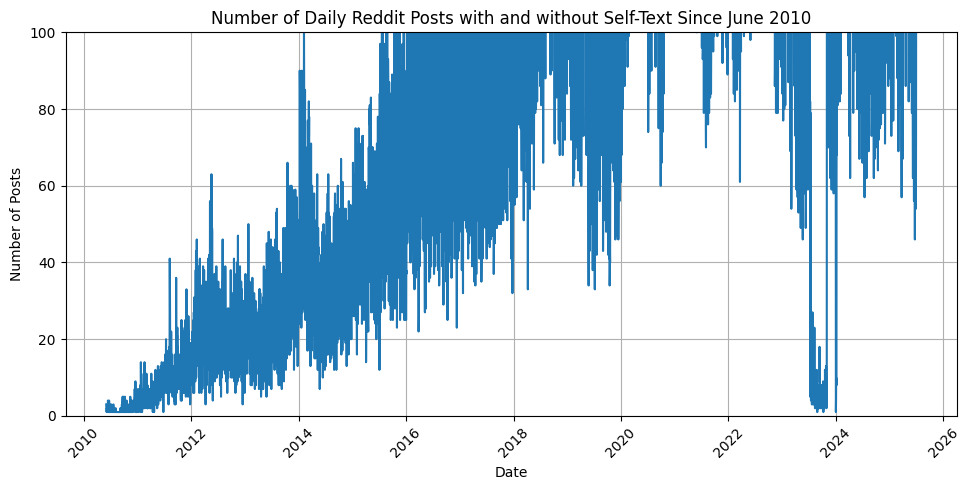

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

df_date_filtered = df[df["created_utc"] >= "2010-06-01"]

# Suppose your DataFrame is called df
# Ensure 'created_utc' is a datetime type
df_date_filtered['created_utc'] = pd.to_datetime(df_date_filtered['created_utc'])

# Group by date and count posts
daily_posts = df_date_filtered.groupby(df_date_filtered['created_utc'].dt.date).size()

# Plot
plt.figure(figsize=(10,5))
daily_posts.plot(kind='line')  # or kind='line' for a line plot
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.title('Number of Daily Reddit Posts with and without Self-Text Since June 2010')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0, 100)
plt.grid()
plt.show()


/var/folders/sz/96b_h5gn3y33k0c7jsvrstmm0000gn/T/ipykernel_23526/332324104.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_date_and_text_filtered['created_utc'] = pd.to_datetime(df_date_and_text_filtered['created_utc'])


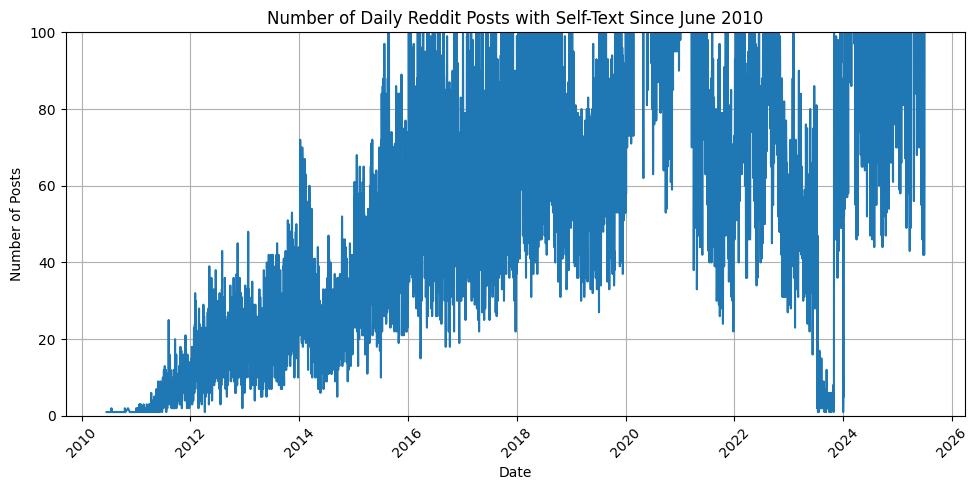

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

df_date_and_text_filtered = df[(df["created_utc"] >= "2010-06-01") & (df["has_selftext"])]

# Suppose your DataFrame is called df
# Ensure 'created_utc' is a datetime type
df_date_and_text_filtered['created_utc'] = pd.to_datetime(df_date_and_text_filtered['created_utc'])

# Group by date and count posts
daily_posts = df_date_and_text_filtered.groupby(df_date_and_text_filtered['created_utc'].dt.date).size()

# Plot
plt.figure(figsize=(10,5))
daily_posts.plot(kind='line')  # or kind='line' for a line plot
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.title('Number of Daily Reddit Posts with Self-Text Since June 2010')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0, 100)
plt.grid()
plt.show()


In [136]:
df_date_and_text_filtered.sort_values(by="created_utc")

,top_comments,submission,subreddit,created_utc,has_selftext
submission_id,,,,,
cgkyb,"[{'id': 't3_c0sruno', 'created_utc': '12773433...","{'author': 'Sidohhz', 'created_utc': 127690298...",stocks,2010-06-18,True
chq3s,"[{'created_utc': '1277253397', 'body': 'With w...","{'author': 'frazer987', 'created_utc': 1277213...",investing,2010-06-22,True
cpwml,[],"{'author': 'disco_biscuit', 'created_utc': 127...",investing,2010-07-15,True
cqrh6,"[{'id': 't3_c0uj0ls', 'author': 'nuuur32', 'bo...","{'author': 'spreaddummy', 'created_utc': 12794...",investing,2010-07-18,True
crulp,"[{'id': 't3_c0uss4v', 'author': 'skimmer', 'sc...","{'author': '[deleted]', 'created_utc': 1279674...",investing,2010-07-21,True
...,...,...,...,...,...
1lo3n4y,"[{'author': 'PutVivid6052', 'body': 'Im too sc...","{'author': 'wsbapp', 'created_utc': 1751277758...",wallstreetbets,2025-06-30,True
1lo3gn1,"[{'author': 'FeelingWatercress871', 'body': 'J...","{'author': 'jayster__', 'created_utc': 1751277...",wallstreetbets,2025-06-30,True
1lo335m,"[{'author': 'jiqiren', 'body': 'Japan doesn’t ...","{'author': 'twenson', 'created_utc': 175127559...",stocks,2025-06-30,True


In [137]:
df_date_filtered.sort_values(by="created_utc")

,top_comments,submission,subreddit,created_utc,has_selftext
submission_id,,,,,
cam6c,[],"{'author': 'EconomyGuy', 'created_utc': 127548...",stocks,2010-06-02,False
calph,[],"{'author': '[deleted]', 'created_utc': 1275482...",stocks,2010-06-02,False
cajvr,[],"{'author': 'gst', 'created_utc': 1275469070, '...",investing,2010-06-02,False
cbjfb,[],"{'author': 'gst', 'created_utc': 1275680132, '...",investing,2010-06-04,False
cbk22,[],"{'author': 'gst', 'created_utc': 1275682943, '...",investing,2010-06-04,False
...,...,...,...,...,...
1lo3n4y,"[{'author': 'PutVivid6052', 'body': 'Im too sc...","{'author': 'wsbapp', 'created_utc': 1751277758...",wallstreetbets,2025-06-30,True
1lo3gn1,"[{'author': 'FeelingWatercress871', 'body': 'J...","{'author': 'jayster__', 'created_utc': 1751277...",wallstreetbets,2025-06-30,True
1lo335m,"[{'author': 'jiqiren', 'body': 'Japan doesn’t ...","{'author': 'twenson', 'created_utc': 175127559...",stocks,2025-06-30,True


- i will be using reddit with selftext only

In [ ]:
# final_data = df_date_and_text_filtered[(df_date_and_text_filtered["created_utc"] >= "2015-07-01") ]
# final_data = final_data.sort_values(by="created_utc")
# final_data = final_data.drop(columns=["has_selftext"])


# final_data["top_comments"] = final_data["top_comments"].apply(json.dumps)
# final_data["submission"] = final_data["submission"].apply(json.dumps)
# final_data.to_parquet(str(PROJECT_ROOT / "01_data/processed/reddit_0.parquet"), index=True)